In [2]:
import os, glob
import scipy
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
# 비전딥러닝 관련 : https://wikidocs.net/135874

In [ ]:
!gdown 1M3Jf3QoxTVy8lDZ4Xb3d9gABu7xPew5A
!unzip chest_xray.zip

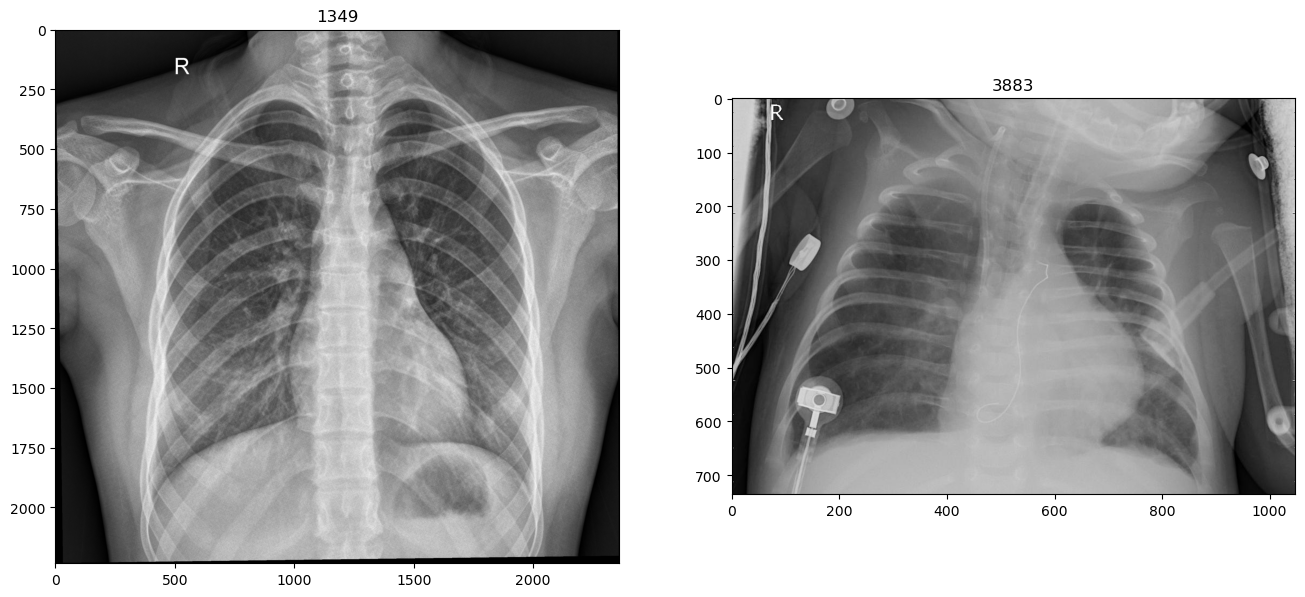

In [3]:
# Preview Dataset
BASE_PATH = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/Medical_practice/MobileNetV2/data'

normal_list = glob.glob(os.path.join(BASE_PATH, 'train/NORMAL/*.jpeg'))
pneumonia_list = glob.glob(os.path.join(BASE_PATH, 'train/PNEUMONIA/*.jpeg'))

normal_img = img_to_array(load_img(normal_list[0]), dtype=np.uint8)
pneumonia_img = img_to_array(load_img(pneumonia_list[0]), dtype=np.uint8)

plt.figure(figsize=(16, 16))
plt.subplot(1, 2, 1)
plt.title(len(normal_list))
plt.imshow(normal_img)
plt.subplot(1, 2, 2)
plt.title(len(pneumonia_list))
plt.imshow(pneumonia_img)

In [4]:
# DataGenerator
# 어그멘테이션

BASE_PATH = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/Medical_practice/MobileNetV2/data/train'

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.01,
    zoom_range=[0.9, 1.1],
    validation_split=0.1, # val 10%
    preprocessing_function=preprocess_input # keras
)

val_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=preprocess_input
)
test_datagen = ImageDataGenerator(
    validation_split=0.1,
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    classes = ['NORMAL', 'PNEUMONIA'],
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    classes = ['NORMAL', 'PNEUMONIA'],
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    subset='validation'
)

test_gen = val_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    classes = ['NORMAL', 'PNEUMONIA'],
    class_mode='categorical',
)

print(val_gen.class_indices)

Found 4710 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 5232 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


In [5]:
# Load Model for Transfer Learning
base_model = MobileNetV2(input_shape=(224, 224, 3), weights='imagenet', include_top=False) #1000이미지 분류 모델

x = base_model.output
x = GlobalAveragePooling2D()(x) # 1차원으로 피기
output = Dense(2, activation='softmax')(x) #[1,0][0,1], 2개

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

model.summary()

2025-05-14 11:04:10.466604: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-05-14 11:04:10.466635: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-05-14 11:04:10.466644: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-05-14 11:04:10.467029: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-14 11:04:10.467226: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [6]:
# Switch Layers to be Trainable # 레이어 웨이트 변경 방지
for layer in model.layers:
        layer.trainable = True

In [7]:
class_weights_dict = {0: 1.2, 1: 0.8}

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[
        ModelCheckpoint('best_model.h5', monitor='val_acc', save_best_only=True, verbose=1) # model.h5 => model.keras
    ]
)

Epoch 1/10


2025-05-14 11:04:16.178213: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


148/148 [==============================] - ETA: 0s - loss: 0.1652 - acc: 0.9372

2025-05-14 11:05:06.402604: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Epoch 1: val_acc improved from -inf to 0.74258, saving model to best_model.h5


/opt/miniconda3/envs/tf-mac/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 56s 317ms/step - loss: 0.1652 - acc: 0.9372 - val_loss: 12.0859 - val_acc: 0.7426
Epoch 2/10
148/148 [==============================] - ETA: 0s - loss: 0.1246 - acc: 0.9454
Epoch 2: val_acc improved from 0.74258 to 0.77608, saving model to best_model.h5
148/148 [==============================] - 45s 304ms/step - loss: 0.1246 - acc: 0.9454 - val_loss: 0.8896 - val_acc: 0.7761
Epoch 3/10
148/148 [==============================] - ETA: 0s - loss: 0.0951 - acc: 0.9628
Epoch 3: val_acc improved from 0.77608 to 0.90813, saving model to best_model.h5
148/148 [==============================] - 46s 306ms/step - loss: 0.0951 - acc: 0.9628 - val_loss: 0.3420 - val_acc: 0.9081
Epoch 4/10
148/148 [==============================] - ETA: 0s - loss: 0.1037 - acc: 0.9580
Epoch 4: val_acc did not improve from 0.90813
148/148 [==============================] - 47s 318ms/step - loss: 0.1037 - acc: 0.9580 - val_loss: 1.1354 - val_acc: 0.8029
Epoch 5/10
148/148 [==

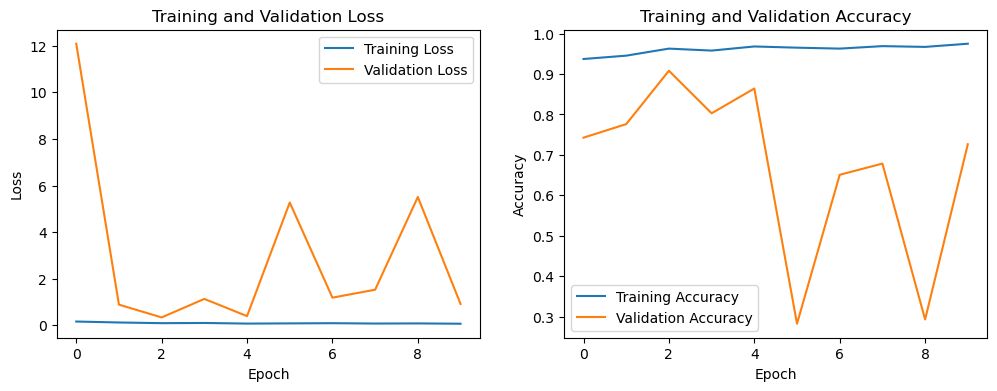

In [13]:
# 학습 로그 출력
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(10), history.history['loss'], label='Training Loss')
plt.plot(range(10), history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(10), history.history['acc'], label='Training Accuracy')
plt.plot(range(10), history.history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [14]:
# Create New Model
model = load_model('best_model.h5')

last_weight = model.layers[-1].get_weights()[0]  # (1280, 1)

new_model = Model(
    inputs=model.input,
    outputs=(
        model.layers[-3].output,  # GAP 바로 앞 feature map
        model.layers[-1].output   # sigmoid 출력
    )
)

new_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

2025-05-14 11:33:40.968661: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 475ms/step


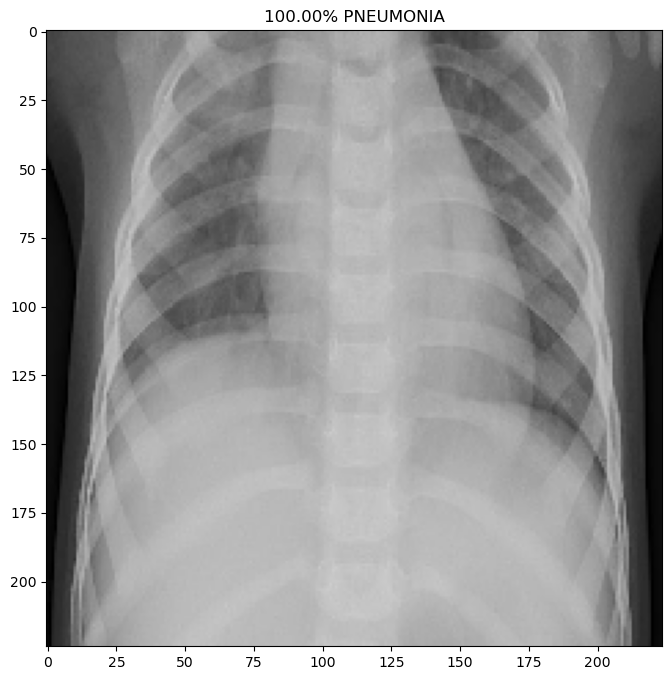

In [15]:
BASE_PATH = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/Medical_practice/MobileNetV2/data/train'  # 폴더 위치
test_img = img_to_array(load_img(os.path.join(BASE_PATH, 'PNEUMONIA/person1_bacteria_1.jpeg'), target_size=(224, 224)))
test_input = preprocess_input(np.expand_dims(test_img.copy(), axis=0))  # (1, 224, 224, 3)

pred = model.predict(test_input)

plt.figure(figsize=(8, 8))
plt.title('%.2f%% PNEUMONIA' % ((1 - pred[0][0]) * 100))  # Free = Normal, class 0
plt.imshow(test_img.astype(np.uint8))

1/1 [==============================] - 0s 19ms/step


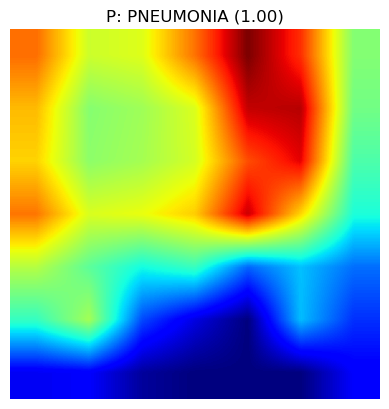

In [20]:
class_labels = ['NORMAL', 'PNEUMONIA']  # 꼭 정의!

# 예측
last_conv_output, pred = new_model.predict(test_input)
last_conv_output = np.squeeze(last_conv_output)  # (7, 7, 1280)

class_idx = np.argmax(pred[0])
predicted_class_weights = last_weight[:, class_idx]

cam = np.dot(last_conv_output, predicted_class_weights)
cam = np.maximum(cam, 0)
cam = cam / np.max(cam)

cam_resized = cv2.resize(cam, (224, 224))

plt.imshow(cam_resized, cmap='jet')
plt.axis('off')
plt.title(f"P: {class_labels[class_idx]} ({pred[0][class_idx]:.2f})")
plt.show()

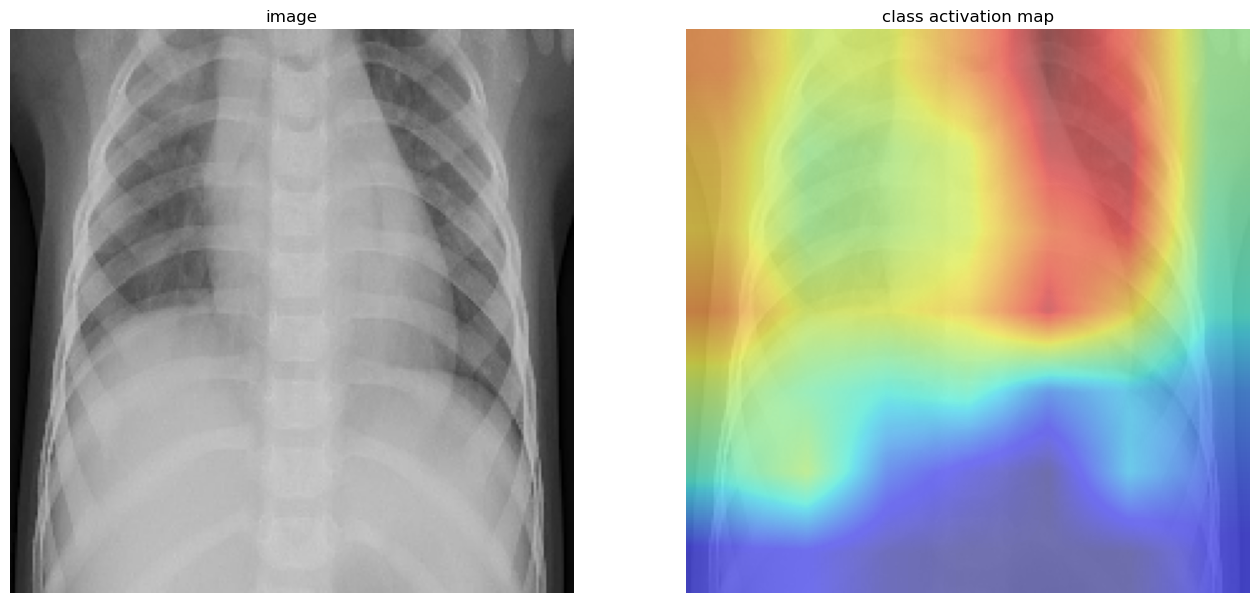

In [29]:
# result
fig, ax = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(16, 20)

ax[0].imshow(test_img.astype(np.uint8))
ax[0].set_title('image')
ax[0].axis('off')

ax[1].imshow(test_img.astype(np.uint8), alpha=0.5)
ax[1].imshow(cam_resized, cmap='jet', alpha=0.5)
ax[1].set_title('class activation map')
ax[1].axis('off')
plt.show()

In [ ]:
y_pred_probs = new_model.predict(val_gen)

for i, out in enumerate(y_pred_probs):
    print(f"output [i] shape: [np.array(out).shape]")  # (32, 2)